# Análisis exploratorio de datos - REHAB
## Ejercicios de entrenamiento

Este notebook aplica los tres bloques de EDA propuestos por Miriam Santos:

1. panorama y estadística descriptiva;
2. evaluación univariada y multivariada;
3. evaluación de calidad.

**Alcance:** únicamente `Rehab_exercise/d02_processed_data`. No se utilizan datos de `Rehab_assessment`.

Referencia: [A Data Scientist's Essential Guide to Exploratory Data Analysis](https://medium.com/data-science/a-data-scientists-essential-guide-to-exploratory-data-analysis-25637eee0cf6).

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#167D8D", "#F29E4C"]
RNG = np.random.default_rng(20260824)

DATA_DIR = Path("/home/andy/Documents/Concentracion/reto/REHAB/Rehab_exercise/d02_processed_data")
assert DATA_DIR.exists(), f"No se encontró la carpeta: {DATA_DIR}"
print(f"Carpeta analizada: {DATA_DIR}")

Carpeta analizada: /home/andy/Documents/Concentracion/reto/REHAB/Rehab_exercise/d02_processed_data


## 1. Inventario y carga segura

Los archivos se cargan con `allow_pickle=False`. Un archivo que no cumpla el formato NumPy queda registrado como incidencia y se excluye de las métricas, sin repararlo silenciosamente.

In [2]:
arrays = {}
incidencias = []

for ruta in sorted(DATA_DIR.glob("*.npy")):
    try:
        arr = np.load(ruta, mmap_mode="r", allow_pickle=False)
        if arr.ndim != 3 or arr.shape[2] != 6:
            raise ValueError(f"forma inesperada: {arr.shape}")
        arrays[ruta.name] = arr
    except Exception as exc:
        incidencias.append({"archivo": ruta.name, "incidencia": f"{type(exc).__name__}: {exc}"})

print(f"Archivos encontrados: {len(list(DATA_DIR.glob('*.npy')))}")
print(f"Archivos válidos: {len(arrays)}")
display(pd.DataFrame(incidencias))

Archivos encontrados: 32
Archivos válidos: 31


,archivo,incidencia
0,014_1.npy,ValueError: Cannot load file containing pickle...


> **Nota:** los nombres de los canales y sufijos se mantienen neutrales. Sin un diccionario de datos no se presupone que representen sensores, lados corporales, sujetos o unidades específicas.

In [3]:
filas = []
muestras = []
for nombre, arr in arrays.items():
    grupo, sufijo = nombre.removesuffix(".npy").split("_")
    x = np.asarray(arr)
    plano = x.reshape(-1, 6)
    desv_ventana = np.std(x, axis=1)
    filas.append({
        "archivo": nombre, "grupo": grupo, "sufijo": sufijo,
        "ventanas": x.shape[0], "longitud": x.shape[1], "canales": x.shape[2],
        "NaN": int(np.isnan(x).sum()), "infinitos": int(np.isinf(x).sum()),
        "ceros": int((x == 0).sum()), "porcentaje_ceros": 100 * float((x == 0).mean()),
        "ventanas_constantes": int(np.all(desv_ventana < 1e-12, axis=1).sum()),
    })
    n = min(20_000, plano.shape[0])
    muestras.append(plano[RNG.choice(plano.shape[0], n, replace=False)])

df_archivos = pd.DataFrame(filas).sort_values(["grupo", "sufijo"]).reset_index(drop=True)
muestra = np.vstack(muestras)

resumen = pd.Series({
    "archivos_válidos": len(arrays),
    "archivos_inválidos": len(incidencias),
    "ventanas": int(df_archivos.ventanas.sum()),
    "longitud_de_ventana": 880,
    "canales": 6,
    "valores_escalares": int((df_archivos.ventanas * 880 * 6).sum()),
    "NaN": int(df_archivos.NaN.sum()),
    "infinitos": int(df_archivos.infinitos.sum()),
    "ceros": int(df_archivos.ceros.sum()),
    "porcentaje_ceros": 100 * df_archivos.ceros.sum() / (df_archivos.ventanas * 880 * 6).sum(),
    "ventanas_constantes": int(df_archivos.ventanas_constantes.sum()),
})
display(resumen.to_frame("resultado"))
display(df_archivos)

,resultado
archivos_válidos,3.100000e+01
archivos_inválidos,1.000000e+00
ventanas,8.873000e+03
longitud_de_ventana,8.800000e+02
canales,6.000000e+00
valores_escalares,4.684944e+07
NaN,0.000000e+00
infinitos,0.000000e+00
ceros,7.545830e+05
porcentaje_ceros,1.610655e+00


,archivo,grupo,sufijo,ventanas,longitud,canales,NaN,infinitos,ceros,porcentaje_ceros,ventanas_constantes
0,000_1.npy,000,1,232,880,6,0,0,0,0.000000,0
1,000_2.npy,000,2,232,880,6,0,0,2,0.000163,0
2,001_1.npy,001,1,212,880,6,0,0,36960,3.301887,7
3,001_2.npy,001,2,212,880,6,0,0,36962,3.302065,7
4,002_1.npy,002,1,267,880,6,0,0,5280,0.374532,1
5,002_2.npy,002,2,267,880,6,0,0,5282,0.374674,1
6,003_1.npy,003,1,250,880,6,0,0,0,0.000000,0
7,003_2.npy,003,2,250,880,6,0,0,0,0.000000,0
8,004_1.npy,004,1,287,880,6,0,0,60720,4.006969,11
9,004_2.npy,004,2,287,880,6,0,0,58082,3.832885,11


## 2. Cobertura de ventanas

sufijo,1,2
grupo,,
000,232.0,232.0
001,212.0,212.0
002,267.0,267.0
003,250.0,250.0
004,287.0,287.0
005,293.0,293.0
006,260.0,260.0
007,385.0,385.0
008,299.0,299.0


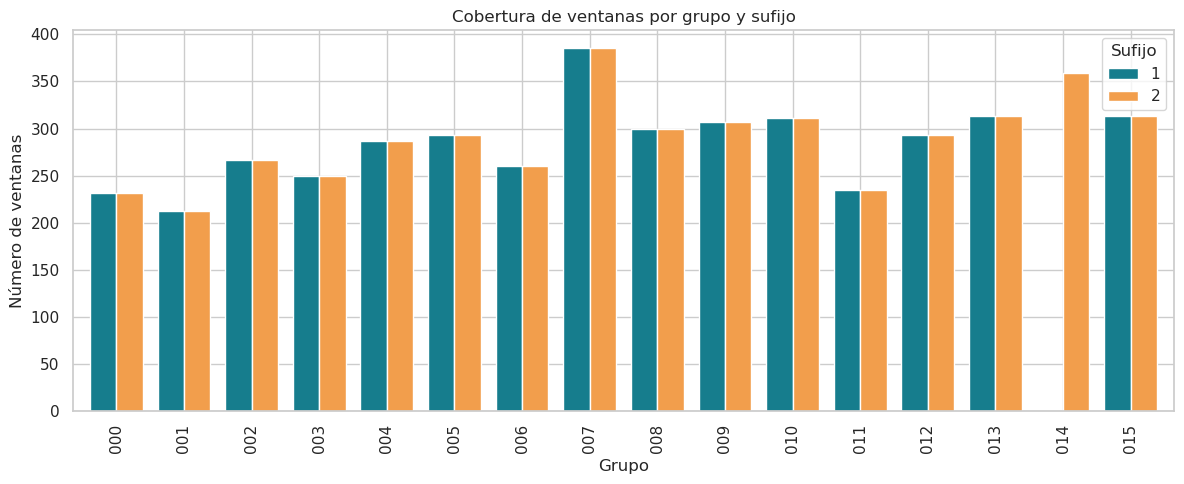

In [4]:
cobertura = df_archivos.pivot(index="grupo", columns="sufijo", values="ventanas")
display(cobertura)

ax = cobertura.plot(kind="bar", figsize=(12, 5), color=PALETTE, width=0.78)
ax.set(title="Cobertura de ventanas por grupo y sufijo", xlabel="Grupo", ylabel="Número de ventanas")
ax.legend(title="Sufijo")
plt.tight_layout(); plt.show()

Los grupos 000-013 y 015 conservan el mismo número de ventanas en ambos sufijos. El grupo 014 queda incompleto porque `014_1.npy` no puede cargarse.

## 3. Estadística descriptiva y distribuciones

,media,desv_est,mínimo,P1,P25,mediana,P75,P99,máximo
C1,-0.014,17.677,-109.333,-49.866,-4.879,0.140,5.871,53.384,125.406
C2,0.047,22.694,-727.015,-68.992,-5.766,0.154,6.300,68.410,378.196
C3,-0.024,24.098,-790.344,-71.989,-6.612,0.187,6.758,70.292,386.822
C4,0.016,18.353,-109.059,-55.136,-6.630,0.298,7.870,46.698,98.736
C5,0.013,18.056,-606.186,-54.310,-3.929,0.108,5.101,56.456,863.207
C6,-0.035,45.838,-450.738,-144.013,-10.137,-0.016,9.420,140.640,578.242


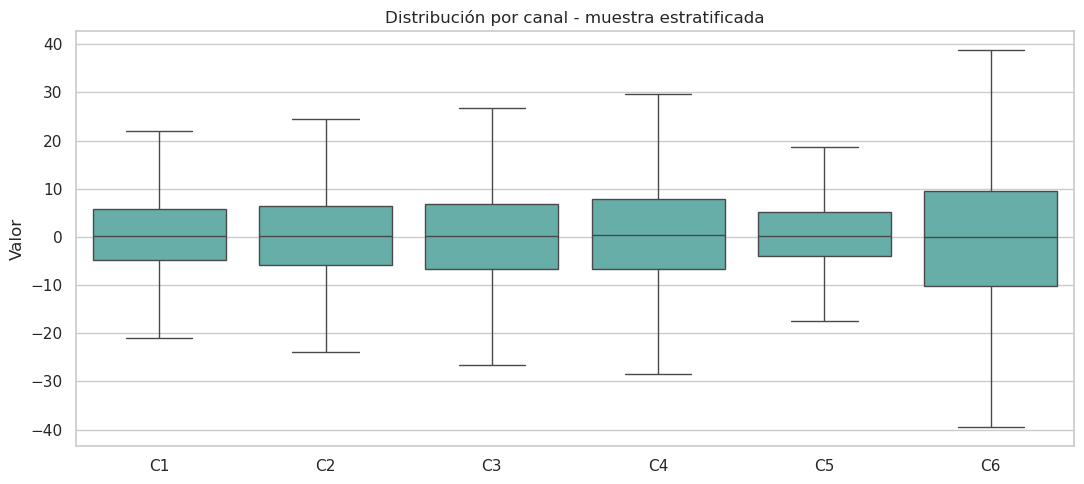

In [5]:
canales = [f"C{i}" for i in range(1, 7)]
estadisticas = pd.DataFrame({
    "media": muestra.mean(axis=0), "desv_est": muestra.std(axis=0),
    "mínimo": muestra.min(axis=0), "P1": np.quantile(muestra, .01, axis=0),
    "P25": np.quantile(muestra, .25, axis=0), "mediana": np.median(muestra, axis=0),
    "P75": np.quantile(muestra, .75, axis=0), "P99": np.quantile(muestra, .99, axis=0),
    "máximo": muestra.max(axis=0),
}, index=canales)
display(estadisticas.round(3))

plt.figure(figsize=(11, 5))
sns.boxplot(data=pd.DataFrame(muestra, columns=canales), showfliers=False, color="#5CB8B2")
plt.title("Distribución por canal - muestra estratificada")
plt.ylabel("Valor"); plt.tight_layout(); plt.show()

Las distribuciones están centradas aproximadamente en cero, pero sus escalas no son equivalentes. El canal 6 presenta la mayor dispersión global; esto justifica evaluar normalización por canal usando parámetros calculados exclusivamente en el fold de entrenamiento.

## 4. Correlaciones e interacciones

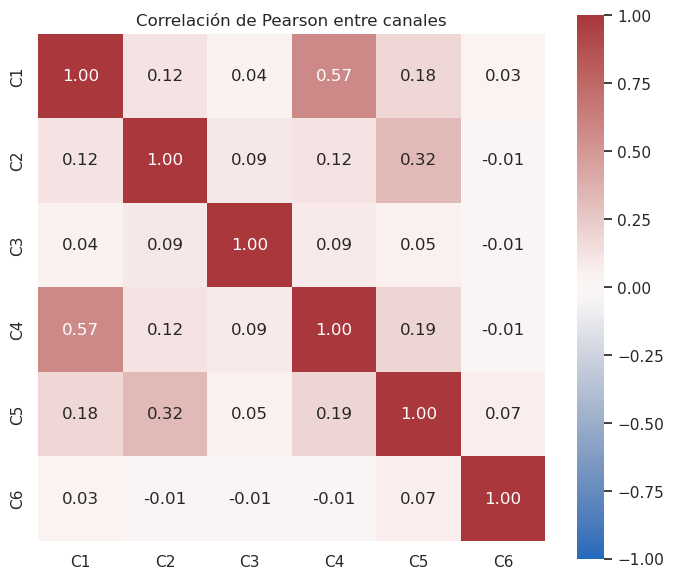

,C1,C2,C3,C4,C5,C6
C1,1.000,0.119,0.040,0.572,0.183,0.035
C2,0.119,1.000,0.094,0.124,0.323,-0.009
C3,0.040,0.094,1.000,0.092,0.052,-0.010
C4,0.572,0.124,0.092,1.000,0.192,-0.010
C5,0.183,0.323,0.052,0.192,1.000,0.067
C6,0.035,-0.009,-0.010,-0.010,0.067,1.000


In [6]:
correlacion = pd.DataFrame(np.corrcoef(muestra, rowvar=False), index=canales, columns=canales)
plt.figure(figsize=(7, 6))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True)
plt.title("Correlación de Pearson entre canales")
plt.tight_layout(); plt.show()
display(correlacion.round(3))

La relación lineal global más fuerte aparece entre C1 y C4; C2-C5 muestra una asociación moderada. No se observan canales totalmente redundantes por correlación lineal global.

## 5. Calidad: ceros y ventanas constantes

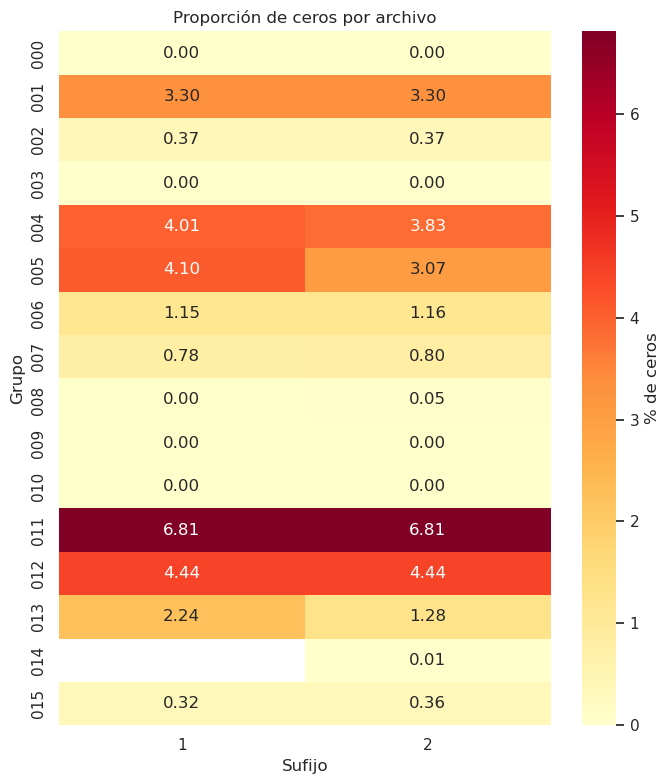

,archivo,porcentaje_ceros,ventanas_constantes
23,011_2.npy,6.808672,16
22,011_1.npy,6.808511,16
24,012_1.npy,4.436860,13
25,012_2.npy,4.436860,13
10,005_1.npy,4.095563,12
8,004_1.npy,4.006969,11
9,004_2.npy,3.832885,11
3,001_2.npy,3.302065,7
2,001_1.npy,3.301887,7
11,005_2.npy,3.071802,9


In [7]:
ceros = df_archivos.pivot(index="grupo", columns="sufijo", values="porcentaje_ceros")
plt.figure(figsize=(7, 8))
sns.heatmap(ceros, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label": "% de ceros"})
plt.title("Proporción de ceros por archivo")
plt.xlabel("Sufijo"); plt.ylabel("Grupo"); plt.tight_layout(); plt.show()

display(df_archivos.nlargest(10, "porcentaje_ceros")[["archivo", "porcentaje_ceros", "ventanas_constantes"]])

Las 142 ventanas constantes son completamente nulas. Deben excluirse o etiquetarse explícitamente antes del modelado, pues no contienen señal.

## 6. Duplicados exactos

In [8]:
ubicaciones = defaultdict(list)
for nombre, arr in arrays.items():
    for i, ventana in enumerate(arr):
        huella = hashlib.blake2b(np.asarray(ventana).tobytes(), digest_size=16).hexdigest()
        ubicaciones[huella].append((nombre, i))

duplicados = [v for v in ubicaciones.values() if len(v) > 1]
duplicados_transversales = [v for v in duplicados if len({x[0] for x in v}) > 1]
metricas_duplicados = pd.Series({
    "grupos_de_patrones_duplicados": len(duplicados),
    "instancias_en_grupos_duplicados": sum(len(v) for v in duplicados),
    "copias_adicionales": sum(len(v) - 1 for v in duplicados),
    "porcentaje_copias_adicionales": 100 * sum(len(v) - 1 for v in duplicados) / resumen["ventanas"],
    "patrones_compartidos_entre_archivos": len(duplicados_transversales),
})
display(metricas_duplicados.to_frame("resultado"))

,resultado
grupos_de_patrones_duplicados,1066.000000
instancias_en_grupos_duplicados,2434.000000
copias_adicionales,1368.000000
porcentaje_copias_adicionales,15.417559
patrones_compartidos_entre_archivos,1.000000


Casi toda la duplicación exacta ocurre dentro del mismo archivo. El único patrón compartido entre archivos corresponde a la ventana completamente nula. Para reducir fuga de información, la división debe hacerse por la unidad independiente más alta disponible -sujeto, sesión o archivo-, una vez confirmada la semántica de los nombres.

## 7. Variabilidad y detección exploratoria de atípicos

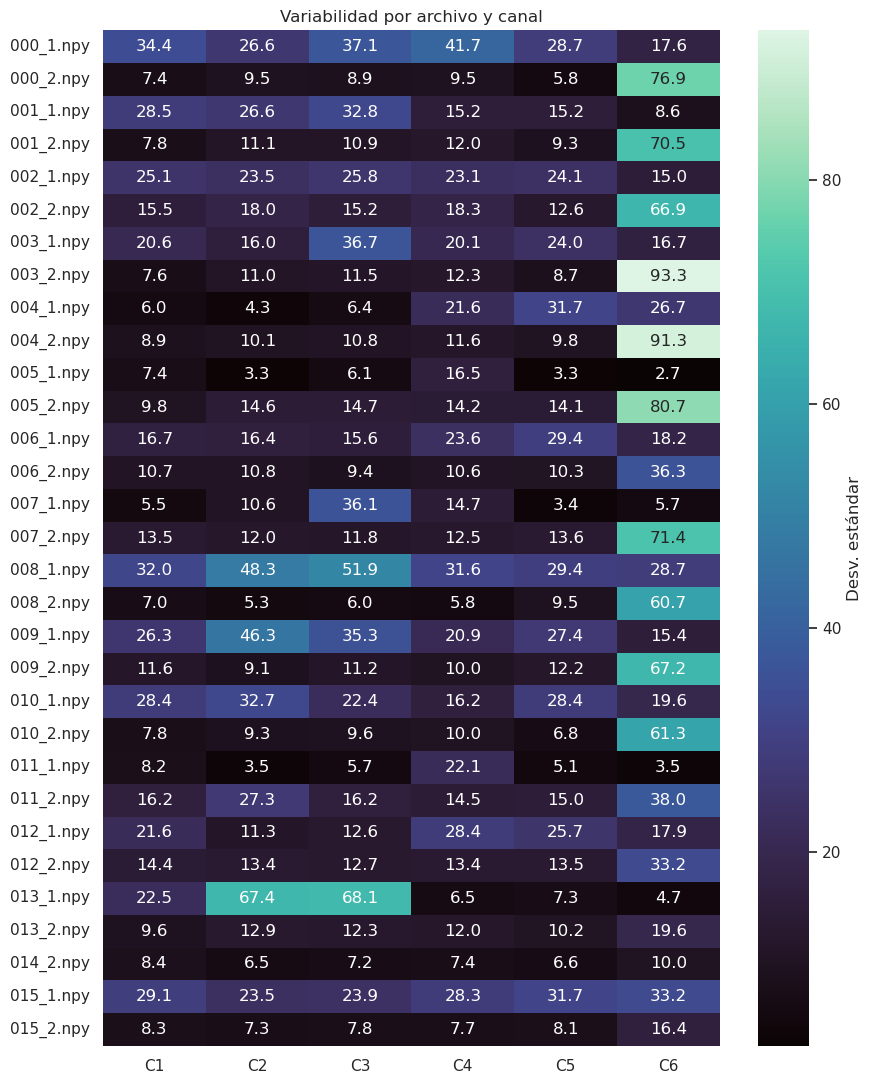

,límite_RMS
C1,49.314
C2,42.794
C3,50.401
C4,46.928
C5,37.019
C6,123.677


,resultado
ventanas_marcadas,1215.000000
porcentaje,13.693227


In [9]:
rms_por_archivo = {}
desv_por_archivo = []
for nombre, arr in arrays.items():
    x = np.asarray(arr)
    rms_por_archivo[nombre] = np.sqrt(np.mean(x*x, axis=1))
    desv_por_archivo.append(pd.Series(np.std(x.reshape(-1, 6), axis=0), index=canales, name=nombre))

df_desv = pd.DataFrame(desv_por_archivo)
plt.figure(figsize=(9, 11))
sns.heatmap(df_desv, annot=True, fmt=".1f", cmap="mako", cbar_kws={"label": "Desv. estándar"})
plt.title("Variabilidad por archivo y canal"); plt.tight_layout(); plt.show()

rms = np.vstack(list(rms_por_archivo.values()))
q1, q3 = np.quantile(rms, [.25, .75], axis=0)
limite = q3 + 1.5 * (q3 - q1)
es_atipica = np.any(rms > limite, axis=1)
resultado_atipicos = pd.Series({
    "ventanas_marcadas": int(es_atipica.sum()),
    "porcentaje": 100 * es_atipica.mean(),
})
display(pd.DataFrame({"límite_RMS": limite}, index=canales).round(3))
display(resultado_atipicos.to_frame("resultado"))

La regla `Q3 + 1.5·IQR` sobre el RMS marca ventanas para revisión, no para eliminación automática. En datos de movimiento, un pico puede representar señal válida y clínicamente relevante.

## 8. Ejemplo de ventana temporal

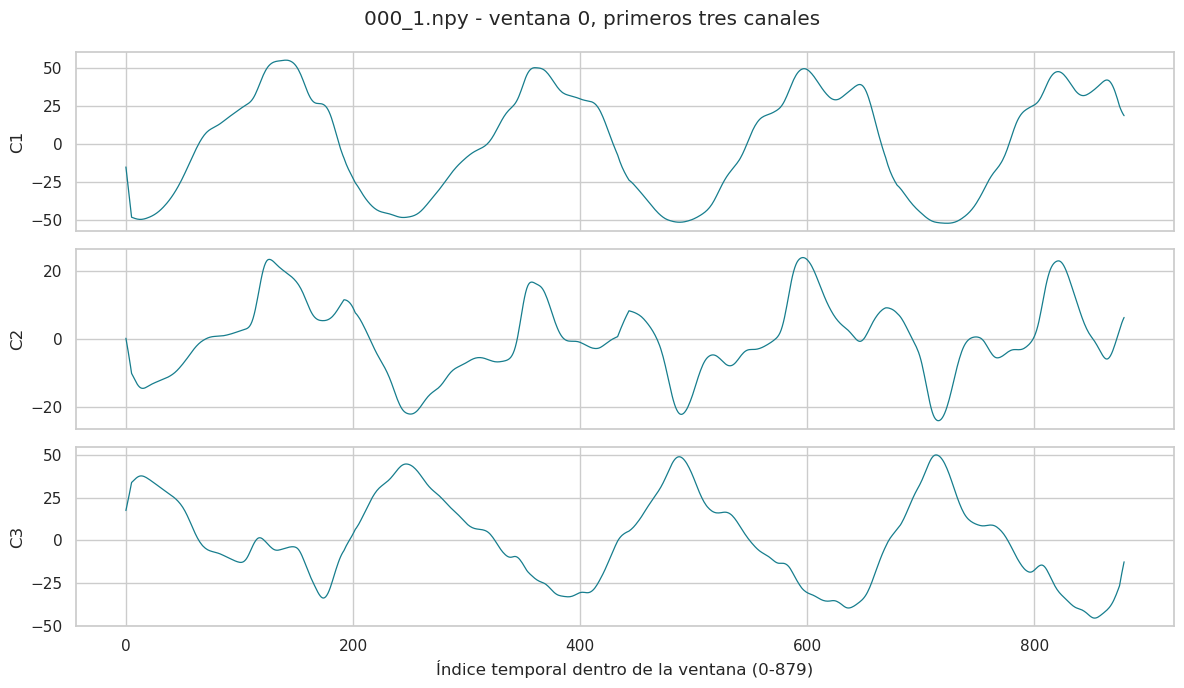

In [10]:
ejemplo = np.asarray(arrays["000_1.npy"][0])
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(ejemplo[:, i], color="#167D8D", linewidth=.9)
    ax.set_ylabel(f"C{i+1}")
axes[-1].set_xlabel("Índice temporal dentro de la ventana (0-879)")
fig.suptitle("000_1.npy - ventana 0, primeros tres canales")
plt.tight_layout(); plt.show()

## 9. Hallazgos y recomendaciones

1. Recuperar o reprocesar `014_1.npy`; el grupo 014 está incompleto.
2. Excluir o etiquetar las 142 ventanas totalmente nulas.
3. Deduplicar dentro de cada archivo o ponderar los patrones repetidos.
4. Crear particiones por sujeto, sesión o archivo; no separar ventanas al azar.
5. Estandarizar por canal con parámetros aprendidos únicamente del fold de entrenamiento.
6. Revisar visualmente los atípicos RMS y contrastarlos con metadatos.
7. Añadir un diccionario de datos con unidades, frecuencia, sensores y significado de grupos/sufijos.

### Conclusión

El conjunto procesado posee buena completitud numérica en los 31 archivos legibles, pero requiere resolver el archivo corrupto, las ventanas nulas y la duplicación exacta antes del entrenamiento. No deben atribuirse significados clínicos a canales o sufijos hasta contar con metadatos.